Used Car Price Prediction Using Machine Learning Regression Models

Objectives

* Predict the Price of used cars.

* Perform data cleaning and preprocessing.

* Handle missing values and duplicate records.

* Conduct Exploratory Data Analysis (EDA).

* Data Visualization

* Train multiple Machine Learning regression models.

* Compare model performances.

* Select the best-performing model

In [82]:
# Importing Libraries
import pandas as pd
import numpy as np

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score

# OLS
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

In [146]:
# Loading Dataset
df = pd.read_excel(r"C:\Users\kkeer\Downloads\car details v4.xlsx")
df

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2054,Mahindra,XUV500 W8 [2015-2017],850000,2016,90300,Diesel,Manual,Surat,White,First,Individual,2179 cc,138 bhp @ 3750 rpm,330 Nm @ 1600 rpm,FWD,4585.0,1890.0,1785.0,7.0,70.0
2055,Hyundai,Eon D-Lite +,275000,2014,83000,Petrol,Manual,Ahmedabad,White,Second,Individual,814 cc,55 bhp @ 5500 rpm,75 Nm @ 4000 rpm,FWD,3495.0,1550.0,1500.0,5.0,32.0
2056,Ford,Figo Duratec Petrol ZXI 1.2,240000,2013,73000,Petrol,Manual,Thane,Silver,First,Individual,1196 cc,70 bhp @ 6250 rpm,102 Nm @ 4000 rpm,FWD,3795.0,1680.0,1427.0,5.0,45.0
2057,BMW,5-Series 520d Luxury Line [2017-2019],4290000,2018,60474,Diesel,Automatic,Coimbatore,White,First,Individual,1995 cc,188 bhp @ 4000 rpm,400 Nm @ 1750 rpm,RWD,4936.0,1868.0,1479.0,5.0,65.0


In [84]:
df.head(3)

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0


In [85]:
# Checking shape
df.shape

(2059, 20)

In [86]:
# Checking Size
df.size

41180

In [87]:
# Checking columns
df.columns

Index(['Make', 'Model', 'Price', 'Year', 'Kilometer', 'Fuel Type',
       'Transmission', 'Location', 'Color', 'Owner', 'Seller Type', 'Engine',
       'Max Power', 'Max Torque', 'Drivetrain', 'Length', 'Width', 'Height',
       'Seating Capacity', 'Fuel Tank Capacity'],
      dtype='object')

In [88]:
# Checking the satistical values
df.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


In [89]:
df.describe(include=object)

,Make,Model,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain
count,2059,2059,2059,2059,2059,2059,2059,2059,1979,1979,1979,1923
unique,33,1050,9,2,77,17,6,3,108,335,290,3
top,Maruti Suzuki,X1 sDrive20d xLine,Diesel,Manual,Mumbai,White,First,Individual,1197 cc,89 bhp @ 4000 rpm,200 Nm @ 1750 rpm,FWD
freq,440,15,1049,1133,342,802,1619,1997,231,90,90,1330


In [90]:
# Checking for the complete information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [91]:
# Feature and Label Identification – X and y
# Target (y) - Price
X = df.drop('Price', axis=1)
y = df['Price']

In [92]:
# Checking for the missing values
df.isnull().sum()

Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64

In [93]:
# Missing Values in Percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

Drivetrain            6.605148
Fuel Tank Capacity    5.488101
Max Torque            3.885381
Max Power             3.885381
Engine                3.885381
Seating Capacity      3.108305
Height                3.108305
Width                 3.108305
Length                3.108305
Model                 0.000000
Make                  0.000000
Owner                 0.000000
Color                 0.000000
Location              0.000000
Transmission          0.000000
Fuel Type             0.000000
Kilometer             0.000000
Year                  0.000000
Price                 0.000000
Seller Type           0.000000
dtype: float64

In [94]:
# Converting Engine, Maxpower, and Max Torque
df['Engine'] = df['Engine'].str.extract(r'(\d+\.?\d*)')[0].astype(float)
df['Max Power'] = df['Max Power'].str.extract(r'(\d+\.?\d*)')[0].astype(float)
df['Max Torque'] = df['Max Torque'].str.extract(r'(\d+\.?\d*)')[0].astype(float)

In [95]:
df[['Engine', 'Max Power', 'Max Torque']].head()

,Engine,Max Power,Max Torque
0,1198.0,87.0,109.0000
1,1248.0,74.0,190.0000
2,1197.0,79.0,112.7619
3,1197.0,82.0,113.0000
4,2393.0,148.0,343.0000


In [96]:
# Handling Missing Values
# For Numerical columns, replacing the missing values by "Median"
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [97]:
# For Categorical columns, replacing the missing values by "Mode"
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [98]:
# Checking null values
df.isnull().sum()

Make                  0
Model                 0
Price                 0
Year                  0
Kilometer             0
Fuel Type             0
Transmission          0
Location              0
Color                 0
Owner                 0
Seller Type           0
Engine                0
Max Power             0
Max Torque            0
Drivetrain            0
Length                0
Width                 0
Height                0
Seating Capacity      0
Fuel Tank Capacity    0
dtype: int64

In [99]:
# Checking for duplicates
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2054    False
2055    False
2056    False
2057    False
2058    False
Length: 2059, dtype: bool

In [100]:
df.duplicated().sum()

np.int64(0)

In [101]:
df.drop_duplicates(inplace=True)

In [102]:
# Checking the data types after cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              2059 non-null   float64
 12  Max Power           2059 non-null   float64
 13  Max Torque          2059 non-null   float64
 14  Drivetrain          2059 non-null   object 
 15  Length              2059 non-null   float64
 16  Width 

In [103]:
# Satistical Understanding
# Discriptive Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,2059.0,1.702992e+06,2.419881e+06,49000.0,484999.0,825000.0,1925000.0,35000000.0
Year,2059.0,2.016425e+03,3.363564e+00,1988.0,2014.0,2017.0,2019.0,2022.0
Kilometer,2059.0,5.422471e+04,5.736172e+04,0.0,29000.0,50000.0,72000.0,2000000.0
Engine,2059.0,1.685016e+03,6.322201e+02,624.0,1198.0,1498.0,1995.0,6592.0
Max Power,2059.0,1.290829e+02,6.385070e+01,35.0,83.0,116.0,169.0,660.0
Max Torque,2059.0,2.440695e+02,1.379934e+02,48.0,115.0,200.0,343.0,780.0
Length,2059.0,4.283631e+03,4.357991e+02,3099.0,3986.0,4370.0,4620.0,5569.0
Width,2059.0,1.768054e+03,1.331464e+02,1475.0,1695.0,1770.0,1831.0,2220.0
Height,2059.0,1.590283e+03,1.341869e+02,1165.0,1485.0,1545.0,1672.0,1995.0
Seating Capacity,2059.0,5.296746e+00,8.110295e-01,2.0,5.0,5.0,5.0,8.0


In [104]:
# Checking Swekness
numeric_df = df.select_dtypes(include=np.number)
numeric_df.skew().sort_values(ascending=False)

Kilometer             20.980719
Price                  4.965143
Max Power              2.131710
Engine                 1.815411
Seating Capacity       1.515381
Max Torque             0.929859
Fuel Tank Capacity     0.898429
Height                 0.877625
Width                  0.311823
Length                -0.040649
Year                  -0.840685
dtype: float64

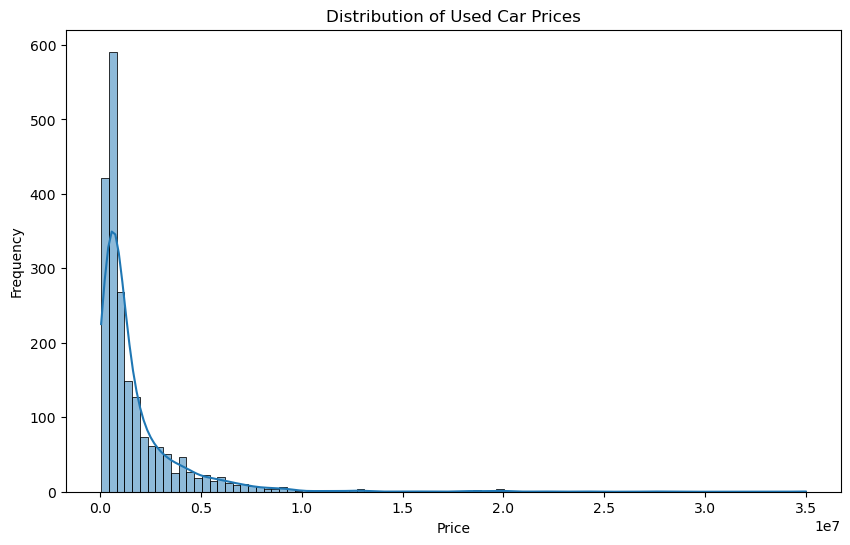

In [105]:
# Data Visualization
# Price Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['Price'], kde=True)
plt.title('Distribution of Used Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

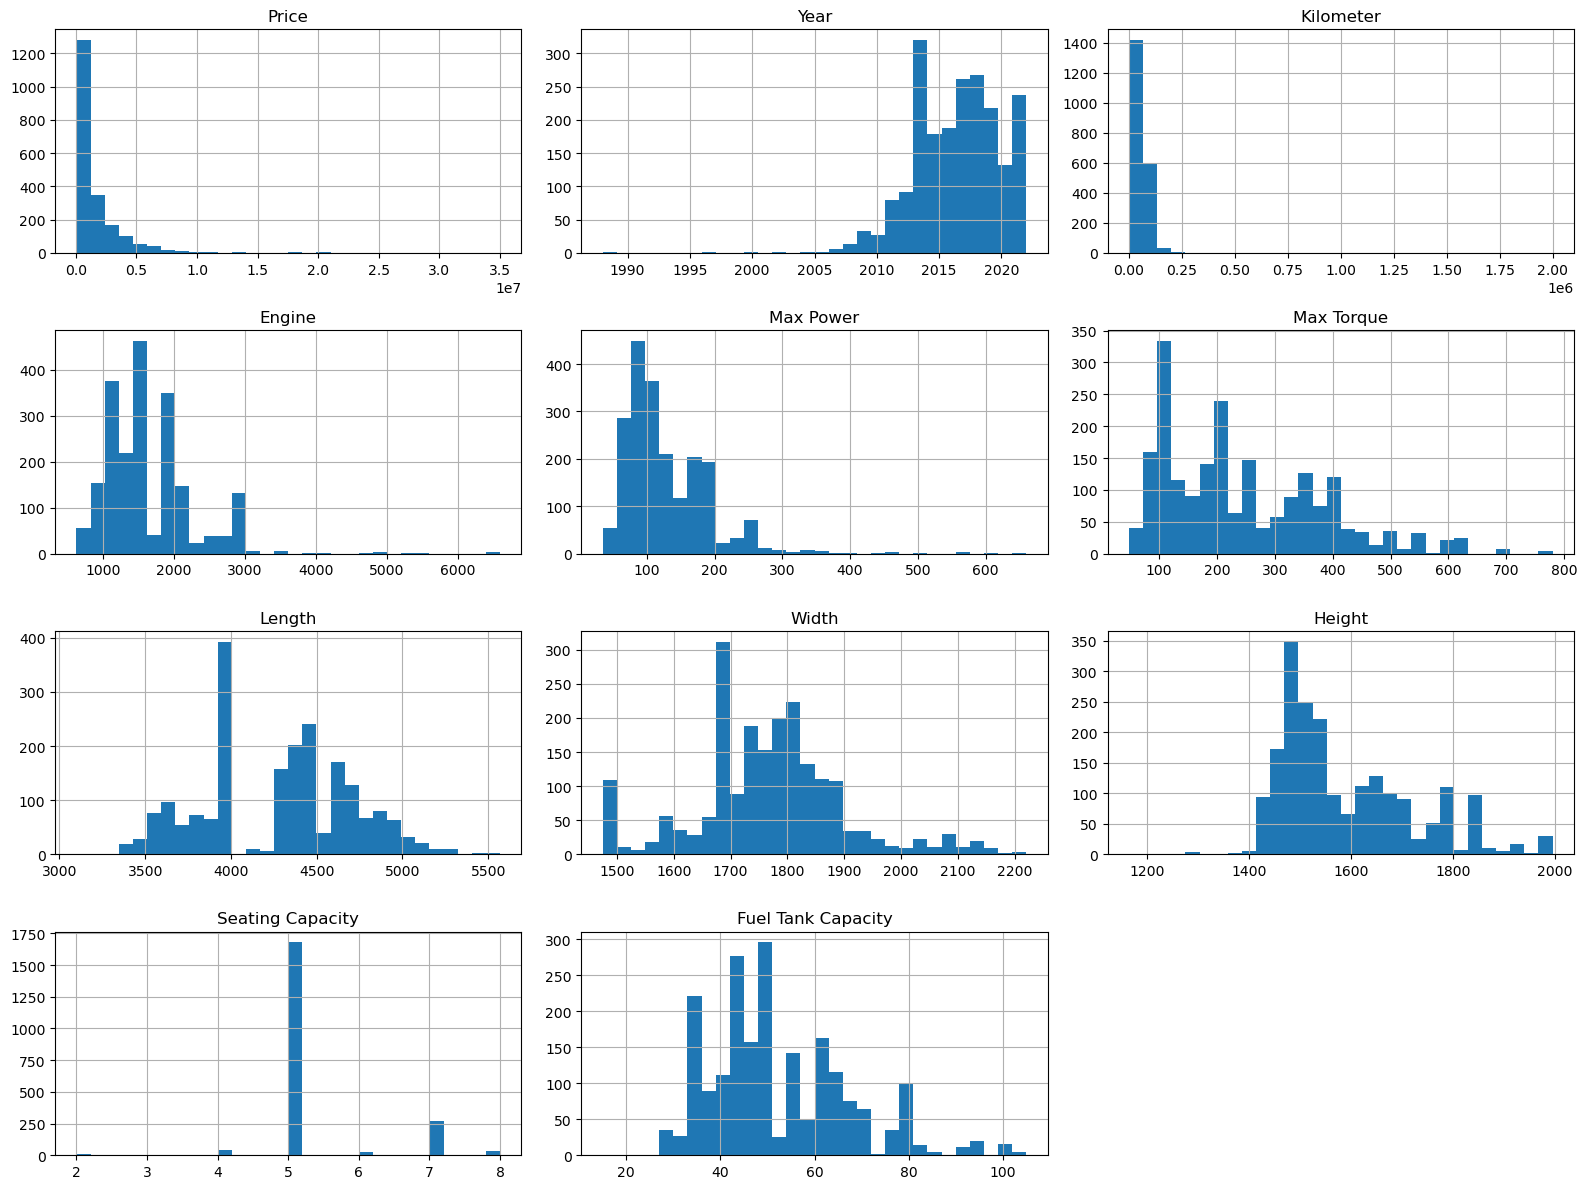

In [106]:
# Histogram for numeric variables
numeric_df = df.select_dtypes(include=np.number)
numeric_df.hist(figsize=(16,12), bins=30)
plt.tight_layout()
plt.show()

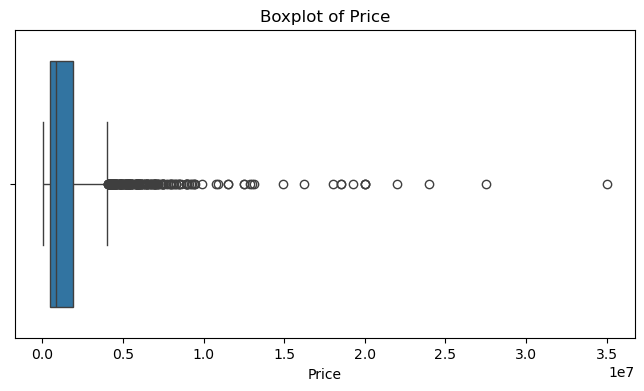

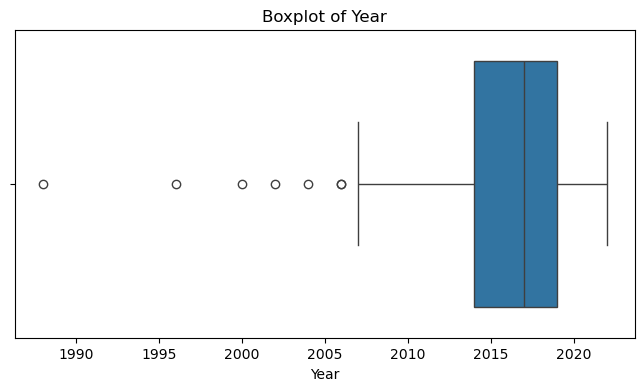

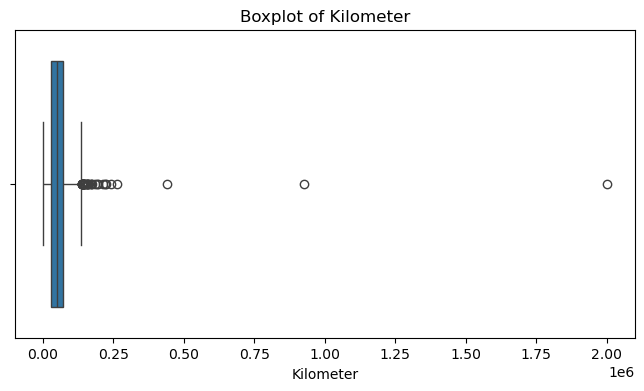

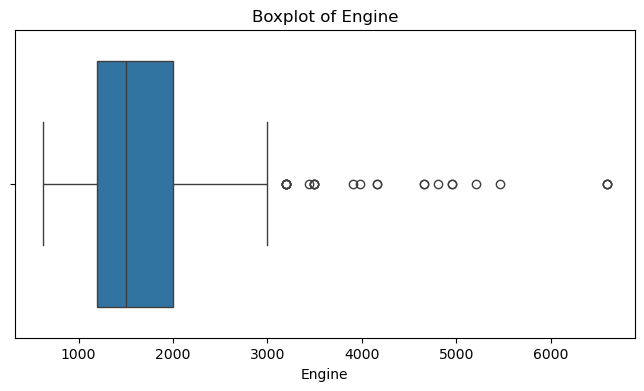

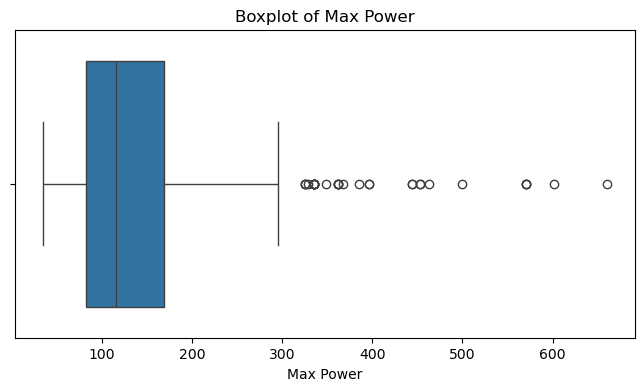

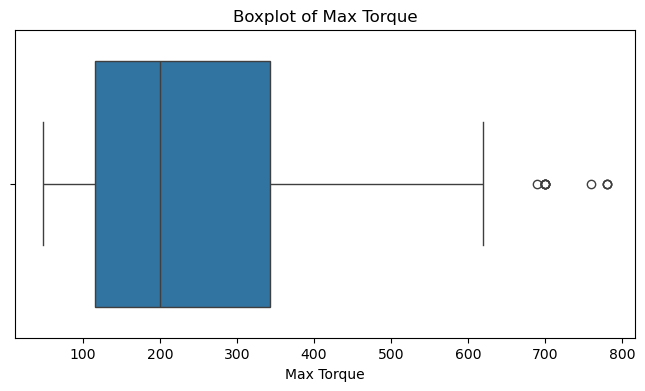

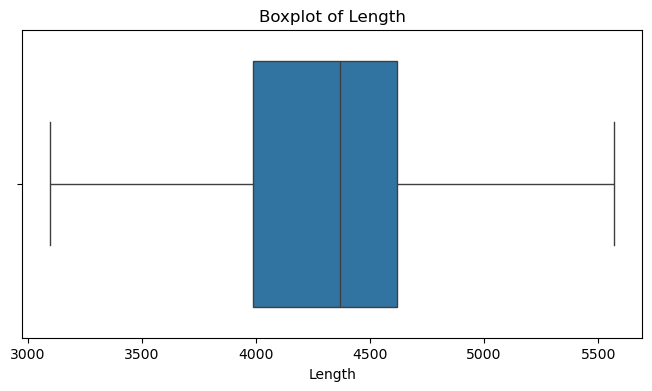

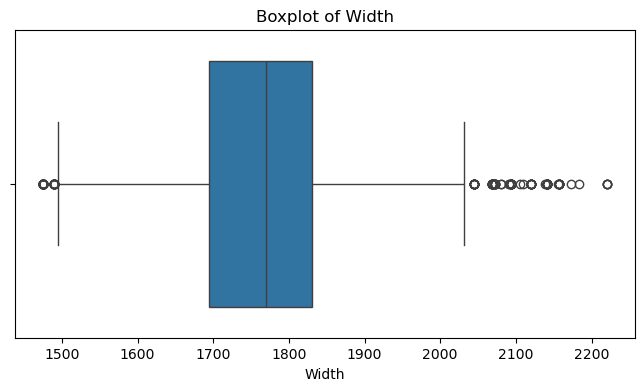

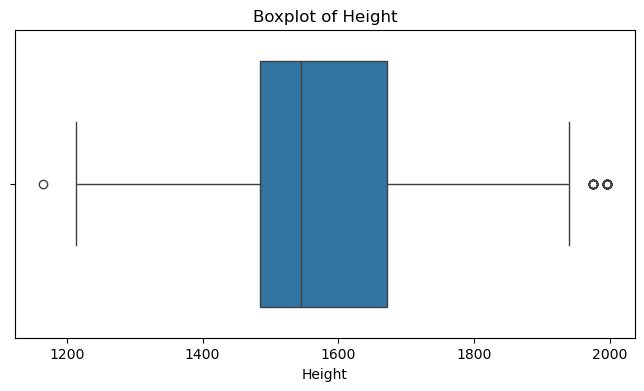

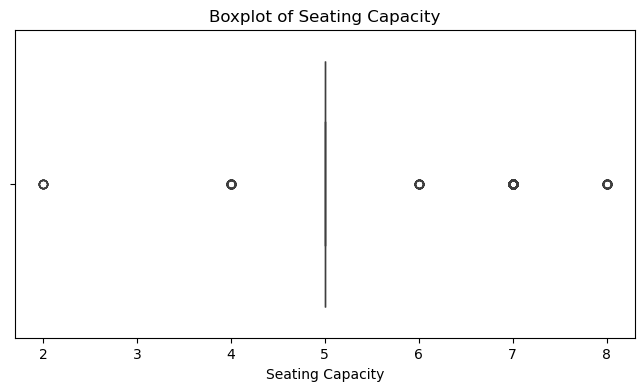

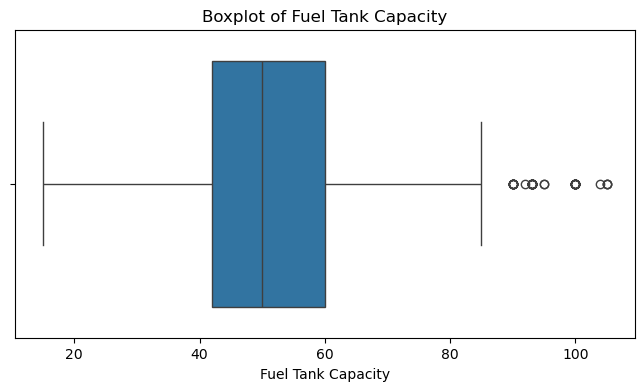

In [107]:
# Box plot - Outlier detection
num_features = df.select_dtypes(include=np.number).columns
for col in num_features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

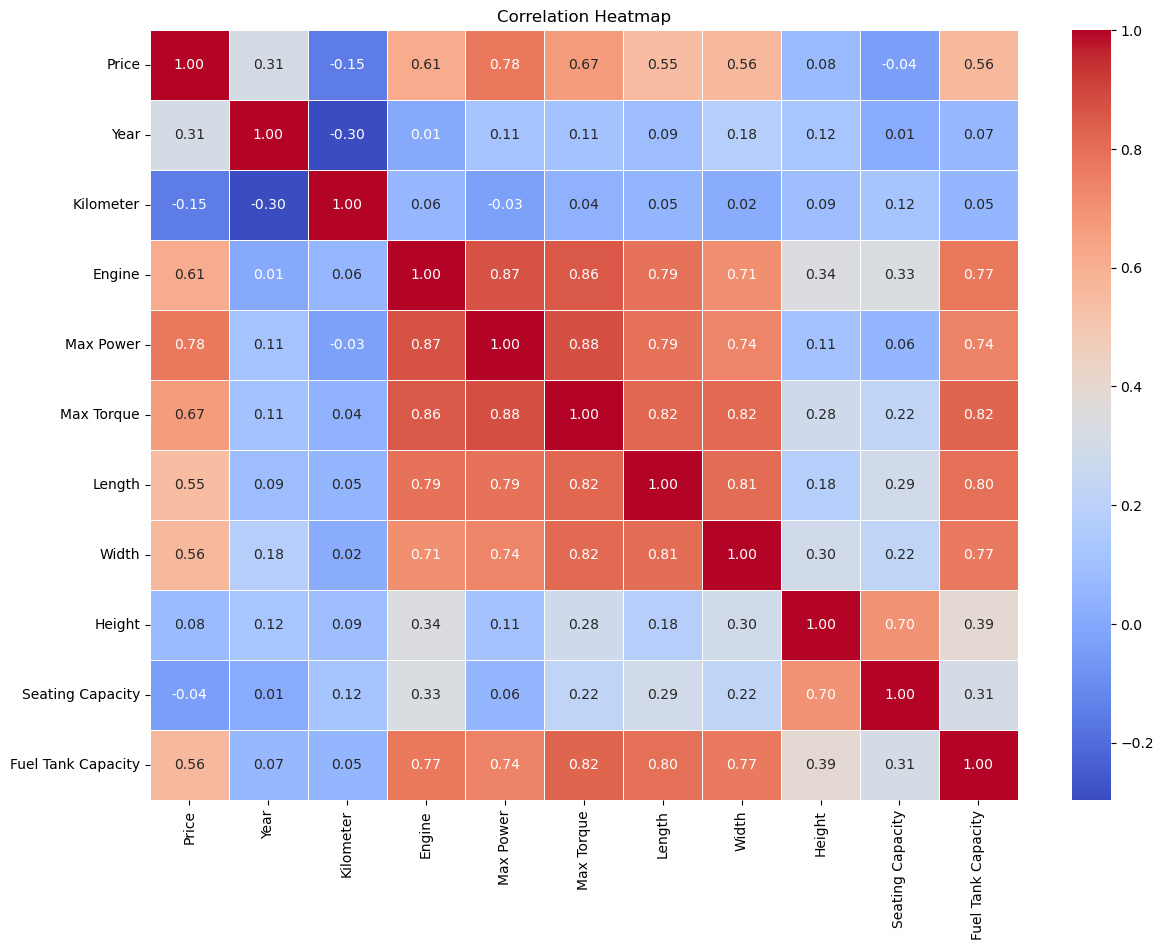

In [108]:
# Correlation analysis - Heat map
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr,  annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

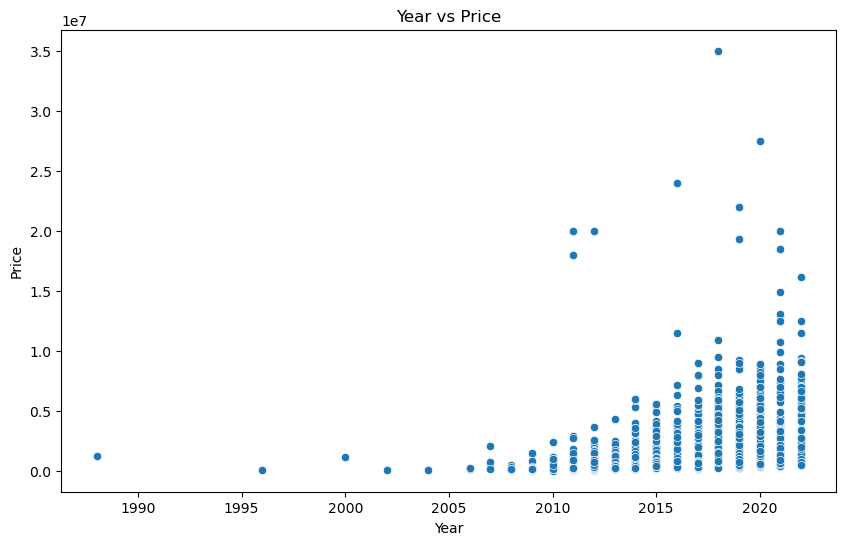

In [109]:
# Scatter plot - year vs price
plt.figure(figsize=(10,6))
sns.scatterplot(x='Year', y='Price', data=df)
plt.title('Year vs Price')
plt.show()

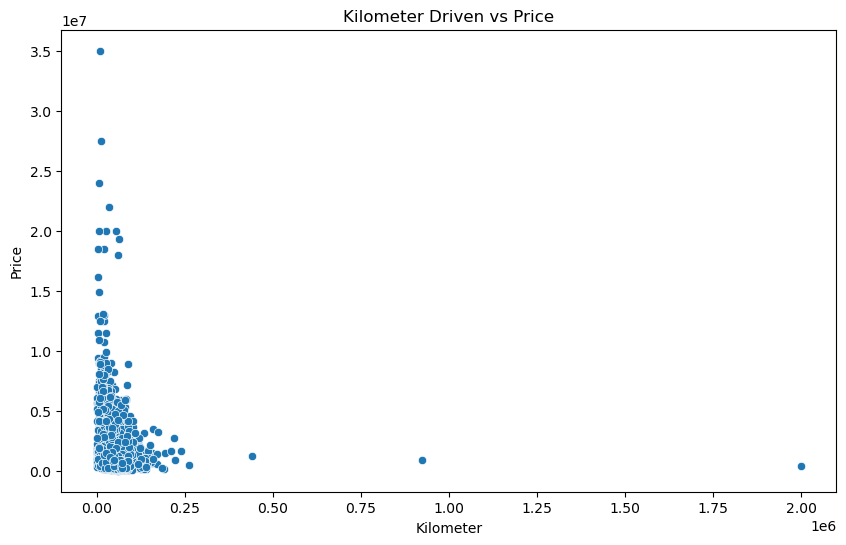

In [110]:
# Kilometer vs price
plt.figure(figsize=(10,6))
sns.scatterplot(x='Kilometer', y='Price', data=df)
plt.title('Kilometer Driven vs Price')
plt.show()

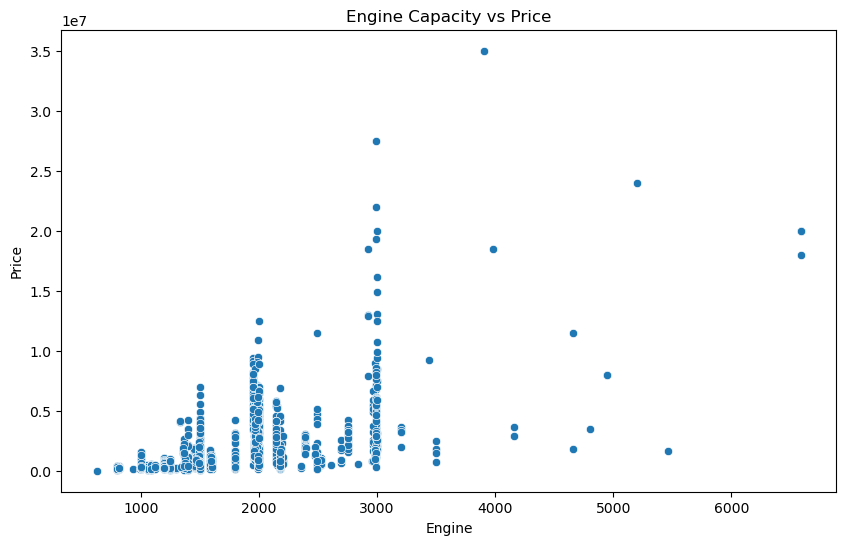

In [111]:
# Engine vs price
plt.figure(figsize=(10,6))
sns.scatterplot(x='Engine', y='Price', data=df)
plt.title('Engine Capacity vs Price')
plt.show()

In [112]:
# Correlation with price
price_corr = corr['Price'].sort_values(ascending=False)
price_corr

Price                 1.000000
Max Power             0.775919
Max Torque            0.666652
Engine                0.611275
Fuel Tank Capacity    0.560842
Width                 0.559786
Length                0.551212
Year                  0.311400
Height                0.076279
Seating Capacity     -0.036116
Kilometer            -0.150825
Name: Price, dtype: float64

In [147]:
# Encoding
#For this project, categorical variables must be converted into numerical variables. We will use "One-Hot Encoding".
# The Model column usually contains a very large number of unique categories. Encoding every model can create a very 
#large number of dummy variables fails in accuracy.
df_model = df.drop('Model', axis=1)

In [114]:
# One-Hot Encoding
df_encoded = pd.get_dummies(df_model, drop_first=True, dtype=int)
df_encoded.head()

,Price,Year,Kilometer,Engine,Max Power,Max Torque,Length,Width,Height,Seating Capacity,...,Color_Yellow,Owner_First,Owner_Fourth,Owner_Second,Owner_Third,Owner_UnRegistered Car,Seller Type_Corporate,Seller Type_Individual,Drivetrain_FWD,Drivetrain_RWD
0,505000,2017,87150,1198.0,87.0,109.0000,3990.0,1680.0,1505.0,5.0,...,0,1,0,0,0,0,1,0,1,0
1,450000,2014,75000,1248.0,74.0,190.0000,3995.0,1695.0,1555.0,5.0,...,0,0,0,1,0,0,0,1,1,0
2,220000,2011,67000,1197.0,79.0,112.7619,3585.0,1595.0,1550.0,5.0,...,0,1,0,0,0,0,0,1,1,0
3,799000,2019,37500,1197.0,82.0,113.0000,3995.0,1745.0,1510.0,5.0,...,0,1,0,0,0,0,0,1,1,0
4,1950000,2018,69000,2393.0,148.0,343.0000,4735.0,1830.0,1795.0,7.0,...,0,1,0,0,0,0,0,1,0,1


In [115]:
df_encoded.shape

(2059, 153)

In [116]:
# Feature and Target seperation for encoding
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

In [117]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (2059, 152)
y Shape: (2059,)


In [118]:
# Train Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [119]:
# Tain and Test shape
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1647, 152)
X_test : (412, 152)
y_train: (1647,)
y_test : (412,)


In [120]:
# Data Leakegare Check
print("Price present in X:", 'Price' in X.columns)

Price present in X: False


In [121]:
# OLS - Oridinary Least Squares
ols_features = ['Year','Kilometer','Engine','Max Power','Max Torque','Length','Width','Height', 'Seating Capacity','Fuel Tank Capacity']
X_ols = df[ols_features]
y_ols = df['Price']

In [122]:
X_ols = sm.add_constant(X_ols)

In [123]:
ols_model = sm.OLS(y_ols, X_ols).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.672
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     419.3
Date:                Thu, 06 Aug 2026   Prob (F-statistic):               0.00
Time:                        19:41:21   Log-Likelihood:                -32040.
No. Observations:                2059   AIC:                         6.410e+04
Df Residuals:                    2048   BIC:                         6.416e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -2.887e+08   2.04

In [124]:
print("OLS R-Squared:", ols_model.rsquared)
print("OLS Adjusted R-Squared:", ols_model.rsquared_adj)

OLS R-Squared: 0.6718538052504874
OLS Adjusted R-Squared: 0.670251528908937


In [125]:
# Model 1 - Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [126]:
y_pred_lr = lr.predict(X_test)

In [127]:
# evaluation for Linear Regression
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred_lr)
n = len(y_test)
p = X_test.shape[1]
lr_adj_r2 = 1 - ((1 - lr_r2) * (n - 1) / (n - p - 1))

In [128]:
# Result
print("Linear Regression")
print("MSE :", lr_mse)
print("RMSE:", lr_rmse)
print("R2  :", lr_r2)
print("Adjusted R2:", lr_adj_r2)

Linear Regression
MSE : 2435867058155.699
RMSE: 1560726.4520586878
R2  : 0.6513357187410342
Adjusted R2: 0.44671421004851375


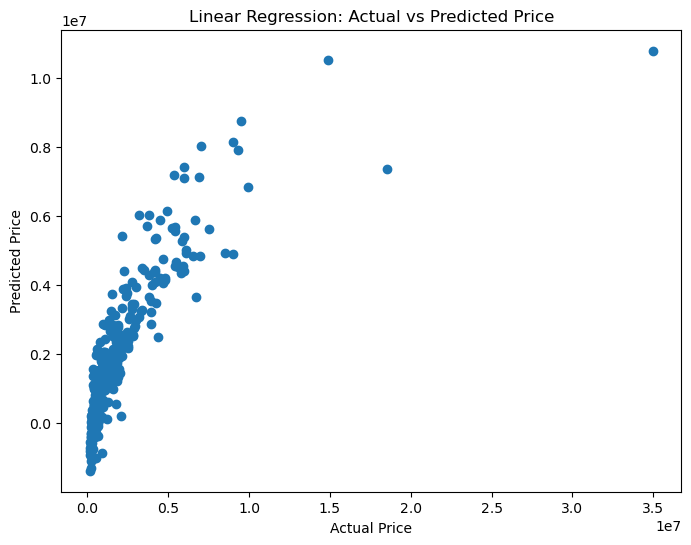

In [129]:
# Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted Price")
plt.show()

In [130]:
# Model 2 - Decision Tree
dt = DecisionTreeRegressor( max_depth=10, min_samples_split=5, random_state=42)
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [131]:
y_pred_dt = dt.predict(X_test)

In [132]:
# Evaluation for Decision Tree
dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, y_pred_dt)
dt_adj_r2 = 1 - ((1 - dt_r2) * (n - 1) / (n - p - 1))

In [133]:
# Result
print("Decision Tree Regression")
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R2  :", dt_r2)
print("Adjusted R2:", dt_adj_r2)

Decision Tree Regression
MSE : 1192234423923.7725
RMSE: 1091894.8776891357
R2  : 0.8293463688349578
Adjusted R2: 0.7291944308539292


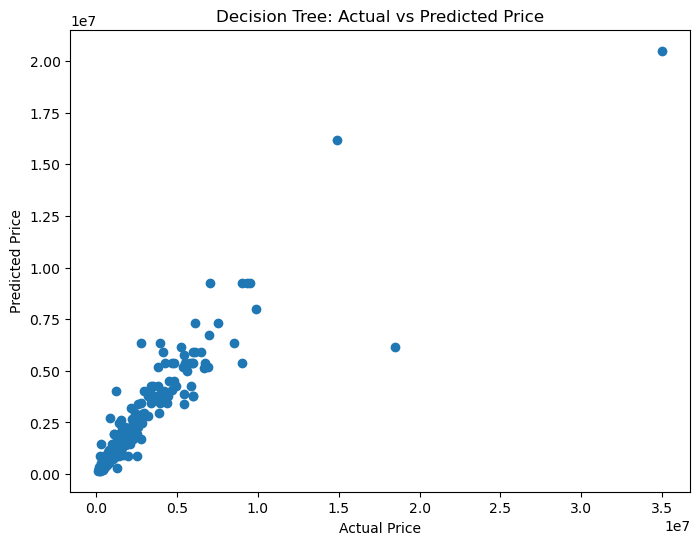

In [134]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_dt)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree: Actual vs Predicted Price")
plt.show()

In [135]:
# Model 3 - Random forest
rf = RandomForestRegressor(n_estimators=200,  max_depth=15,  min_samples_split=5,  random_state=42)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [136]:
y_pred_rf = rf.predict(X_test)

In [137]:
# Evaluation for Random forest
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)
rf_adj_r2 = 1 - ((1 - rf_r2) * (n - 1) / (n - p - 1))

In [138]:
# Result
print("Random Forest Regression")
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)
print("Adjusted R2:", rf_adj_r2)

Random Forest Regression
MSE : 1324956337985.5864
RMSE: 1151067.4775987663
R2  : 0.8103488662336813
Adjusted R2: 0.6990478147569228


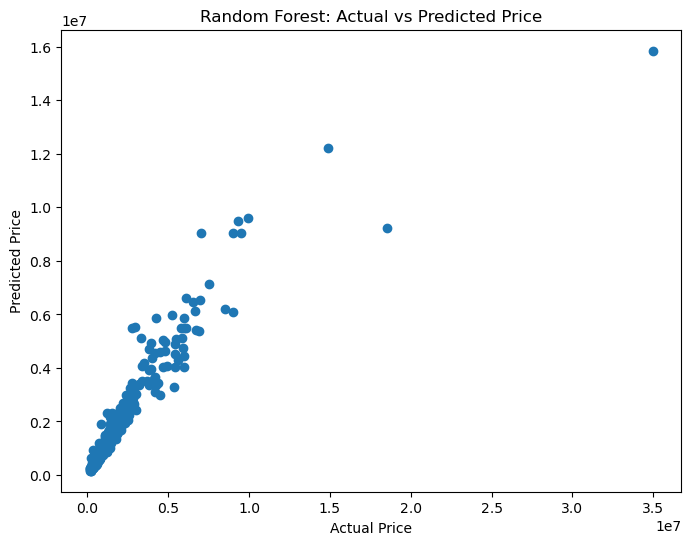

In [139]:
# Actual vs Predicted for Randon forest
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted Price")
plt.show()

In [140]:
# Model comparision
results = pd.DataFrame({'Model':['Linear Regression', 'Decision Tree',  'Random Forest'],'MSE': [lr_mse,dt_mse,rf_mse],
                        'RMSE': [ lr_rmse,dt_rmse,rf_rmse],'R2 Score': [ lr_r2,dt_r2,rf_r2],
                         'Adjusted R2': [lr_adj_r2,dt_adj_r2, rf_adj_r2]})
results

,Model,MSE,RMSE,R2 Score,Adjusted R2
0,Linear Regression,2.435867e+12,1.560726e+06,0.651336,0.446714
1,Decision Tree,1.192234e+12,1.091895e+06,0.829346,0.729194
2,Random Forest,1.324956e+12,1.151067e+06,0.810349,0.699048


In [141]:
results.sort_values(by='R2 Score', ascending=False)

,Model,MSE,RMSE,R2 Score,Adjusted R2
1,Decision Tree,1.192234e+12,1.091895e+06,0.829346,0.729194
2,Random Forest,1.324956e+12,1.151067e+06,0.810349,0.699048
0,Linear Regression,2.435867e+12,1.560726e+06,0.651336,0.446714


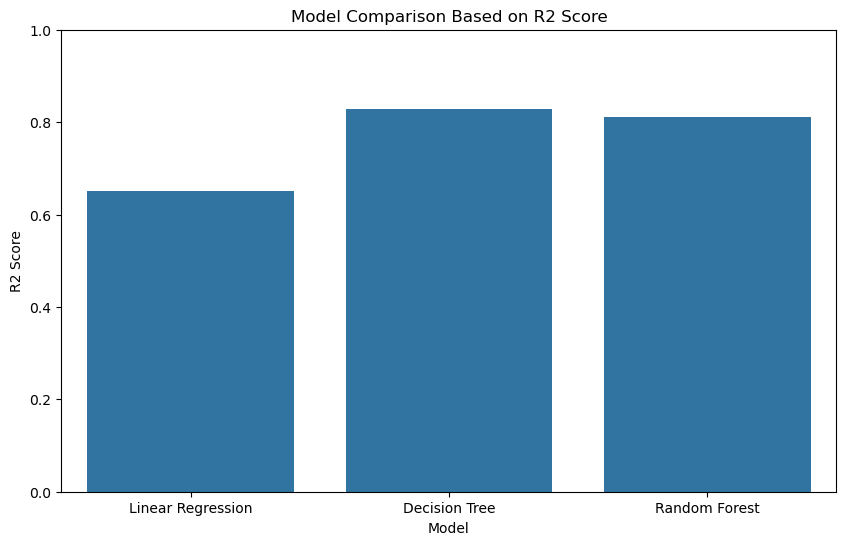

In [142]:
# Model comparizing visualization
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='R2 Score',data=results)
plt.title('Model Comparison Based on R2 Score')
plt.ylim(0, 1)
plt.show()

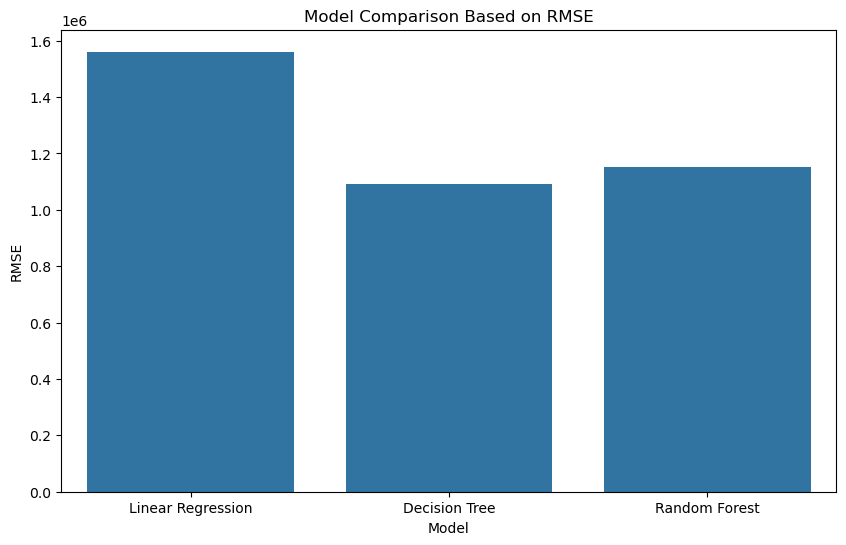

In [143]:
# RMSE Comparision
plt.figure(figsize=(10,6))
sns.barplot(x='Model',y='RMSE',data=results)
plt.title('Model Comparison Based on RMSE')
plt.show()

In [144]:
# Best model
best_model = results.loc[results['R2 Score'].idxmax()]
best_model

Model                 Decision Tree
MSE            1192234423923.772461
RMSE                 1091894.877689
R2 Score                   0.829346
Adjusted R2                0.729194
Name: 1, dtype: object

In [145]:
print("Best Model:", best_model['Model'])
print("R2 Score:", best_model['R2 Score'])
print("RMSE:", best_model['RMSE'])

Best Model: Decision Tree
R2 Score: 0.8293463688349578
RMSE: 1091894.8776891357
